# IMDB Movie Review Sentiment Analysis — Completed Professional Solution

This notebook completes the supplied exercise using the required **TensorFlow/Keras neural-network architecture**:

`Embedding → GlobalAveragePooling1D → Dense(16, relu) → Dropout(0.5) → Dense(1, sigmoid)`

The workflow is deliberately leakage-safe: the Keras tokenizer is fitted **only on the training set**, while validation and test data are used only for transformation/evaluation.

**Dataset:** `IMDB Dataset.csv`


## Step 0 — Setup

The exercise requires TensorFlow/Keras, NLTK preprocessing, pandas, matplotlib, seaborn, and scikit-learn.


In [1]:
# If packages are missing, run this once in a notebook cell:
# %pip install -U nltk scikit-learn tensorflow pandas matplotlib seaborn
# ============================================================
# Step 0: Setup
# ============================================================

import os
import re
import string
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import tensorflow as tf

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Download required NLTK resources
# ------------------------------------------------------------

print("Downloading/checking NLTK resources...")

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("NLTK resources are ready.")

# ------------------------------------------------------------
# Display versions
# ------------------------------------------------------------

print("\nEnvironment:")
print("Python environment: Ready")
print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)
print("NLTK version:", nltk.__version__)

print("\nSetup completed successfully.")

Downloading/checking NLTK resources...
NLTK resources are ready.

Environment:
Python environment: Ready
TensorFlow version: 2.21.0
Pandas version: 2.2.3
NLTK version: 3.9.1

Setup completed successfully.


## Step 1 — Load & Explore the Data

In [2]:
# Load the supplied CSV. Keep this filename if the CSV is in the same folder
# as the notebook; otherwise replace it with the correct path.
DATA_PATH = "IMDB Dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Put the CSV beside this notebook "
        "or update DATA_PATH to its full path."
    )

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())


Shape: (50000, 2)

Columns: ['review', 'sentiment']

Data types:
review       object
sentiment    object
dtype: object

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Class counts:
sentiment
negative    25000
positive    25000
Name: count, dtype: int64

Class proportions:
sentiment
negative    0.5
positive    0.5
Name: count, dtype: float64


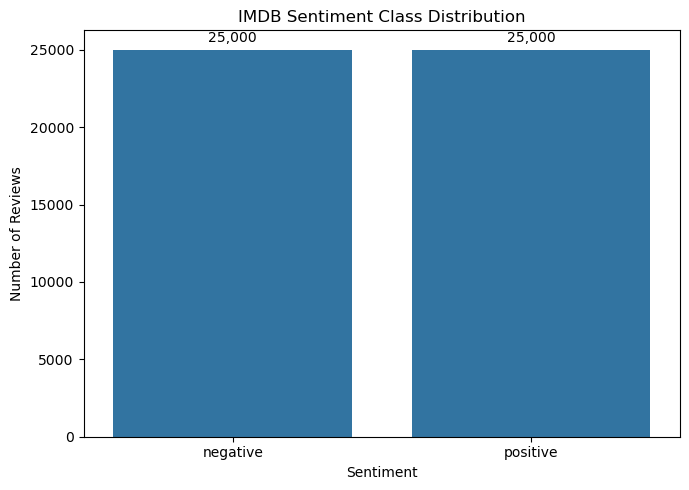

In [3]:
# Class balance
class_counts = df["sentiment"].value_counts().reindex(["negative", "positive"])

print("Class counts:")
print(class_counts)
print("\nClass proportions:")
print((class_counts / len(df)).round(4))

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("IMDB Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

for i, value in enumerate(class_counts.values):
    ax.text(i, value + len(df) * 0.01, f"{value:,}", ha="center")

plt.tight_layout()
plt.show()


In [4]:
# Missing values and duplicate reviews
print("Missing values before cleaning:")
print(df.isna().sum())

duplicate_count = df.duplicated(subset=["review"]).sum()
print(f"\nDuplicate reviews found: {duplicate_count:,}")

# Handle missing values conservatively.
df = df.dropna(subset=["review", "sentiment"]).copy()

# Remove exact duplicate reviews so that the same text is not represented
# multiple times and potentially appear across train/validation/test.
df = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

print("\nShape after removing missing/duplicate reviews:", df.shape)
print("Missing values after cleaning:")
print(df.isna().sum())


Missing values before cleaning:
review       0
sentiment    0
dtype: int64

Duplicate reviews found: 418

Shape after removing missing/duplicate reviews: (49582, 2)
Missing values after cleaning:
review       0
sentiment    0
dtype: int64


50th percentile: 173 words
90th percentile: 452 words
95th percentile: 591 words
99th percentile: 908 words
Maximum: 2470 words


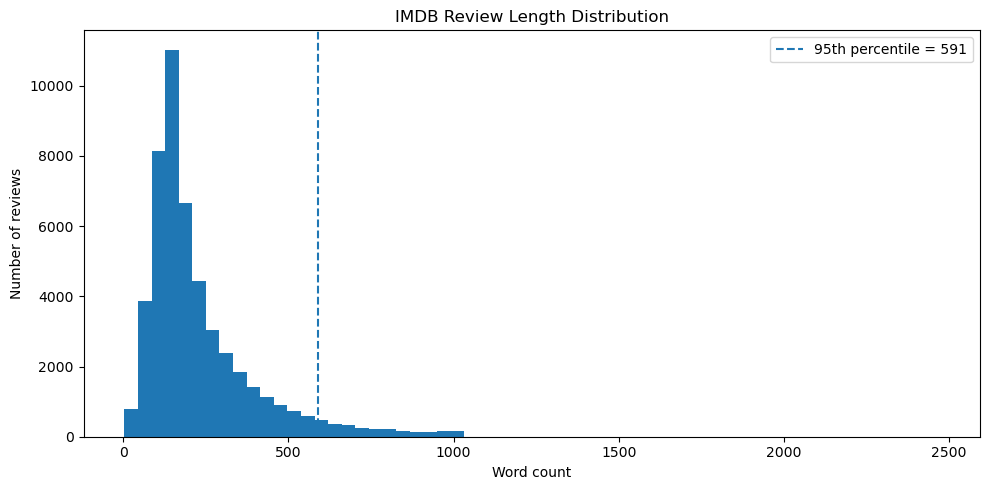

In [5]:
# Review-length distribution using raw word counts.
df["raw_word_count"] = df["review"].str.split().str.len()

q90 = df["raw_word_count"].quantile(0.90)
q95 = df["raw_word_count"].quantile(0.95)
q99 = df["raw_word_count"].quantile(0.99)

print(f"50th percentile: {df['raw_word_count'].quantile(0.50):.0f} words")
print(f"90th percentile: {q90:.0f} words")
print(f"95th percentile: {q95:.0f} words")
print(f"99th percentile: {q99:.0f} words")
print(f"Maximum: {df['raw_word_count'].max():.0f} words")

plt.figure(figsize=(10, 5))
plt.hist(df["raw_word_count"], bins=60)
plt.axvline(q95, linestyle="--", label=f"95th percentile = {q95:.0f}")
plt.title("IMDB Review Length Distribution")
plt.xlabel("Word count")
plt.ylabel("Number of reviews")
plt.legend()
plt.tight_layout()
plt.show()


## Step 2 — Text Cleaning (Preprocessing Part A)

The cleaning policy is intentionally conservative for sentiment analysis:

- Remove HTML tags such as `<br />`.
- Remove URLs.
- Convert text to lowercase.
- Expand common negation contractions such as `isn't → is not`, because negation is highly informative for sentiment.
- Remove remaining punctuation and non-alphabetic characters.
- Collapse repeated whitespace.

This means we do **not** simply delete negation information during cleaning.


In [6]:
CONTRACTION_MAP = {
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "won't": "will not",
    "wouldn't": "would not",
    "can't": "can not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "mustn't": "must not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "mightn't": "might not",
    "needn't": "need not",
    "shan't": "shall not",
}

def clean_text(text: str) -> str:
    """Clean one raw IMDB review while preserving explicit negation words."""
    if not isinstance(text, str):
        return ""

    text = re.sub(r"<[^>]+>", " ", text)                  # HTML
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # URLs
    text = text.lower()

    # Preserve sentiment-bearing negation by expanding common contractions.
    for contraction, expansion in CONTRACTION_MAP.items():
        text = re.sub(
            rf"\b{re.escape(contraction)}\b",
            expansion,
            text,
        )

    # Keep only alphabetic characters and whitespace.
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["review_clean"] = df["review"].map(clean_text)

# Sanity check: original vs cleaned examples.
examples = df[["review", "review_clean"]].head(3).copy()
display(examples)


,review,review_clean
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...


## Step 3 — Tokenization & Linguistic Preprocessing

### Decision: keep negation words

For sentiment analysis, words such as **not, no, never, neither, nor** can reverse or strongly modify sentiment. Removing them as ordinary stopwords can turn:

> "not good"

into something equivalent to:

> "good"

Therefore, these negation terms are explicitly removed from the stopword set.

### Decision: stemming

We use **Porter stemming** because it is lightweight and fast for 50,000 reviews. Stemming reduces related forms to a common root, which can reduce vocabulary size.

The trade-off is that stemming can produce non-dictionary roots (for example, several related words may become an artificial stem). Lemmatization is linguistically cleaner but usually requires more computation and linguistic resources. For this exercise, stemming is a reasonable engineering trade-off.


In [7]:
# Negation-aware stopword list.
stop_words = set(stopwords.words("english"))
NEGATION_WORDS = {
    "not", "no", "never", "neither", "nor",
    "none", "nobody", "nothing", "nowhere"
}
stop_words = stop_words - NEGATION_WORDS

stemmer = PorterStemmer()

def preprocess_tokens(text: str) -> str:
    """Tokenize, remove non-negation stopwords, stem, and rejoin."""
    tokens = word_tokenize(text)

    processed = [
        stemmer.stem(token)
        for token in tokens
        if token.isalpha() and token not in stop_words
    ]

    return " ".join(processed)

df["review_final"] = df["review_clean"].map(preprocess_tokens)

print("Preprocessing examples:")
display(df[["review", "review_clean", "review_final"]].head(3))


Preprocessing examples:


,review,review_clean,review_final
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...


## Step 4 — Encode Labels & Split the Data

In [8]:
# Encode labels: positive = 1, negative = 0.
df["label"] = df["sentiment"].map({"negative": 0, "positive": 1}).astype(int)

X = df["review_final"]
y = df["label"]

# 70% train, 15% validation, 15% test.
# First split 70/30, then split the 30% temporary set equally.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED,
)

print(f"Train:      {len(X_train):,} ({len(X_train)/len(df):.1%})")
print(f"Validation: {len(X_val):,} ({len(X_val)/len(df):.1%})")
print(f"Test:       {len(X_test):,} ({len(X_test)/len(df):.1%})")

split_summary = pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "validation": y_val.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
split_summary.index = ["negative (0)", "positive (1)"]
display(split_summary)

# Reset indices for clean downstream handling.
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


Train:      34,707 (70.0%)
Validation: 7,437 (15.0%)
Test:       7,438 (15.0%)


,train,validation,test
negative (0),17288,3705,3705
positive (1),17419,3732,3733


## Step 5 — Text Vectorization for the Neural Network

In [9]:
# Vocabulary size is deliberately capped to control model size.
VOCAB_SIZE = 15000

# Choose a padding length using the review-length analysis.
# We use a practical upper bound around the 95th percentile.
processed_train_lengths = X_train.str.split().str.len()
p95_processed = int(np.ceil(processed_train_lengths.quantile(0.95)))

# Keep the value practical for CPU training while still covering most reviews.
MAX_LEN = int(np.clip(p95_processed, 150, 300))

print(f"95th percentile of processed training-review length: {p95_processed}")
print(f"Selected MAX_LEN: {MAX_LEN}")

# IMPORTANT: fit only on training text to avoid vocabulary leakage.
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>",
)
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    train_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
)
X_val_pad = pad_sequences(
    val_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
)
X_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post",
)

print("\nPadded shapes:")
print("X_train_pad:", X_train_pad.shape)
print("X_val_pad:  ", X_val_pad.shape)
print("X_test_pad: ", X_test_pad.shape)

actual_vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"\nTokenizer vocabulary size available to model: {actual_vocab_size:,}")


95th percentile of processed training-review length: 313
Selected MAX_LEN: 300

Padded shapes:
X_train_pad: (34707, 300)
X_val_pad:   (7437, 300)
X_test_pad:  (7438, 300)

Tokenizer vocabulary size available to model: 15,000


## Step 6 — Build the Neural Network

The required architecture is used **exactly as specified**:

`Embedding → GlobalAveragePooling1D → Dense(16, relu) → Dropout(0.5) → Dense(1, sigmoid)`

The embedding learns a vector representation for each word. Global average pooling converts the variable-length sequence into one fixed-size review representation. The dense layers then perform binary classification.

A limitation is that GlobalAveragePooling1D largely ignores word order, so phrases where order changes meaning can be difficult for the model.


In [10]:
EMBEDDING_DIM = 16

model = Sequential([
    Embedding(
        input_dim=actual_vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN,
    ),
    GlobalAveragePooling1D(),
    Dense(16, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

model.summary()


C:\Users\biniyam\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 7 — Train the Model

In [11]:
# Stop when validation loss stops improving.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

checkpoint_path = "best_imdb_sentiment_model.keras"
model_checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

callbacks = [early_stopping, model_checkpoint]

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/15
539/543 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5975 - loss: 0.6585
Epoch 1: val_loss improved from None to 0.52676, saving model to best_imdb_sentiment_model.keras

Epoch 1: finished saving model to best_imdb_sentiment_model.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.5986 - loss: 0.6578 - val_accuracy: 0.7807 - val_loss: 0.5268
Epoch 2/15
538/543 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8195 - loss: 0.4360
Epoch 2: val_loss improved from 0.52676 to 0.34771, saving model to best_imdb_sentiment_model.keras

Epoch 2: finished saving model to best_imdb_sentiment_model.keras
543/543 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8198 - loss: 0.4356 - val_accuracy: 0.8642 - val_loss: 0.3477
Epoch 3/15
538/543 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8687 - loss: 0.3387
Epoch 3: val_loss improved from 0.34771 to 0.29586, saving model to best_imdb_sentiment_model.keras

Epoch 3: finished saving model to best_imdb_sentiment_model.keras
543/543 

## Step 8 — Evaluate

Training and validation curves are used to diagnose fit quality.

Typical interpretation:
- **Overfitting:** training loss keeps decreasing while validation loss rises, or training accuracy keeps improving while validation accuracy stagnates/degrades.
- **Underfitting:** both training and validation performance remain poor.
- **Reasonably fit:** training and validation curves improve together and remain relatively close.

The exact conclusion must be based on the curves produced by the actual run.


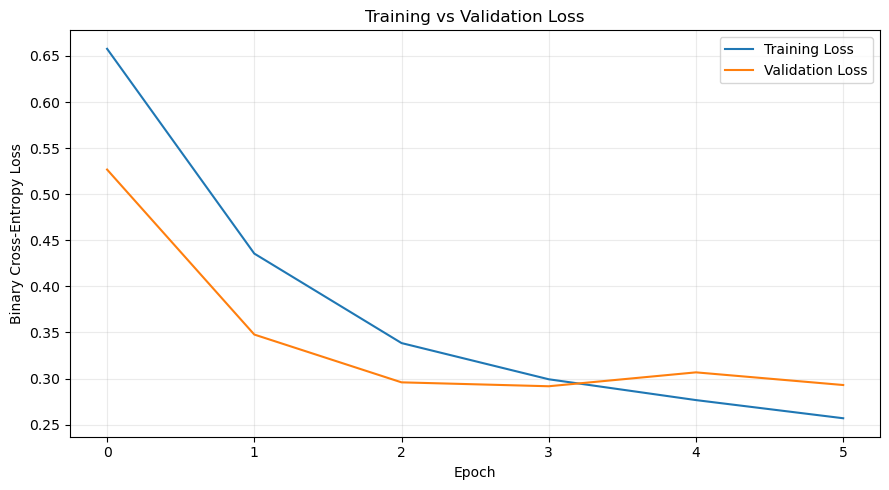

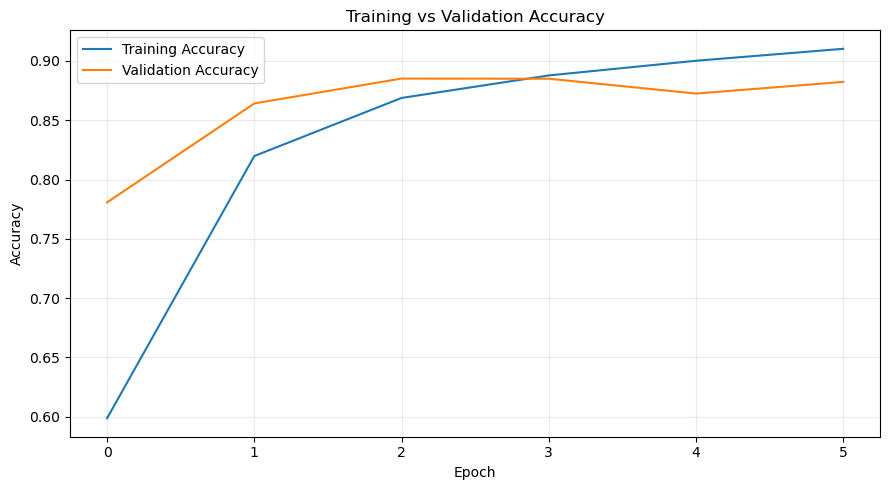

In [12]:
# Plot training vs validation loss.
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot training vs validation accuracy.
plt.figure(figsize=(9, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


Test loss:      0.2954
Test accuracy:  0.8824
Test precision: 0.8518
Test recall:    0.9269
Test F1-score:  0.8877

Classification report:
              precision    recall  f1-score   support

    negative     0.9191    0.8375    0.8764      3705
    positive     0.8518    0.9269    0.8877      3733

    accuracy                         0.8824      7438
   macro avg     0.8855    0.8822    0.8821      7438
weighted avg     0.8853    0.8824    0.8821      7438



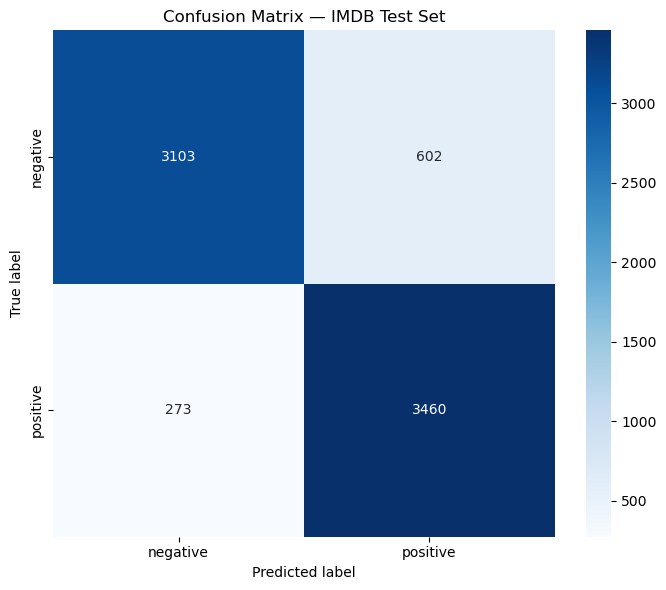

,Metric,Score
0,Accuracy,0.882361
1,Precision,0.851797
2,Recall,0.926868
3,F1-score,0.887749


In [13]:
# Held-out test-set evaluation.
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0,
)

y_prob = model.predict(X_test_pad, batch_size=256, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"Test loss:      {test_loss:.4f}")
print(f"Test accuracy:  {accuracy:.4f}")
print(f"Test precision: {precision:.4f}")
print(f"Test recall:    {recall:.4f}")
print(f"Test F1-score:  {f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["negative", "positive"],
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
)
plt.title("Confusion Matrix — IMDB Test Set")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1],
})
display(metrics_df)


In [14]:
# Automatic, evidence-based diagnostic from the final recorded epoch.
train_acc = history.history["accuracy"][-1]
val_acc = history.history["val_accuracy"][-1]
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print("Model-fit diagnostic:")
print(f"Final training accuracy:   {train_acc:.4f}")
print(f"Final validation accuracy: {val_acc:.4f}")
print(f"Final training loss:       {train_loss:.4f}")
print(f"Final validation loss:     {val_loss:.4f}")

acc_gap = train_acc - val_acc

if val_loss > train_loss * 1.20 and acc_gap > 0.03:
    diagnosis = "There are signs of overfitting."
elif train_acc < 0.70 and val_acc < 0.70:
    diagnosis = "There are signs of underfitting."
else:
    diagnosis = "The model appears reasonably fit; inspect the curves for any late-epoch divergence."

print("\nDiagnosis:", diagnosis)


Model-fit diagnostic:
Final training accuracy:   0.9103
Final validation accuracy: 0.8823
Final training loss:       0.2569
Final validation loss:     0.2930

Diagnosis: The model appears reasonably fit; inspect the curves for any late-epoch divergence.


### Discussion

The final diagnosis should be based on the plots and test metrics above. If validation loss starts increasing while training loss continues falling, that is evidence of overfitting; EarlyStopping helps limit this effect. If both training and validation performance remain low, the model is underfitting.

For improvement, a senior-level next step would be to test changes **one at a time**: vocabulary size, maximum sequence length, embedding dimension, regularization, learning rate, or a more expressive sequence model. However, LSTM/GRU/Conv1D should not replace the required architecture for the graded exercise.


## Step 9 — Inference on New Reviews

In [15]:
def predict_sentiment(text: str):
    """Run the complete preprocessing + neural-network inference pipeline."""
    cleaned = clean_text(text)
    processed = preprocess_tokens(cleaned)

    sequence = tokenizer.texts_to_sequences([processed])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post",
    )

    probability = float(model.predict(padded, verbose=0)[0][0])
    label = "positive" if probability >= 0.5 else "negative"

    return label, probability


# Three self-written test cases required by the exercise.
new_reviews = {
    "Clearly positive": (
        "This movie was fantastic. The performances were excellent, "
        "the story was engaging, and I loved every minute of it."
    ),
    "Clearly negative": (
        "This movie was terrible. The acting was boring, the story was weak, "
        "and I regretted spending my time watching it."
    ),
    "Ambiguous / sarcastic": (
        "Absolutely brilliant movie — if your idea of entertainment is "
        "watching paint dry for two hours."
    ),
}

inference_results = []

for case, review in new_reviews.items():
    label, probability = predict_sentiment(review)
    inference_results.append({
        "Case": case,
        "Review": review,
        "Prediction": label,
        "Positive probability": probability,
    })

inference_df = pd.DataFrame(inference_results)
display(inference_df)


,Case,Review,Prediction,Positive probability
0,Clearly positive,This movie was fantastic. The performances wer...,positive,0.887494
1,Clearly negative,This movie was terrible. The acting was boring...,negative,0.184114
2,Ambiguous / sarcastic,Absolutely brilliant movie — if your idea of e...,positive,0.703450


### Inference discussion

The clearly positive and clearly negative examples are expected to be easier for the model because their sentiment-bearing vocabulary is explicit.

The sarcastic example is intentionally difficult. The required architecture uses global average pooling, which discards most word-order information and has limited ability to understand sarcasm, pragmatics, or context. Therefore, an incorrect prediction on the sarcastic example is not surprising and illustrates a real limitation of this simple model.


## Step 10 — Optional Bonus: TF-IDF + Logistic Regression Baseline

In [17]:
# ============================================================
# Step 10 — Optional Bonus
# TF-IDF + Logistic Regression Baseline
# ============================================================

# Import the required libraries explicitly.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 70)
print("TF-IDF + Logistic Regression Baseline")
print("=" * 70)

# ------------------------------------------------------------
# 1. TF-IDF Vectorization
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# IMPORTANT:
# Fit TF-IDF ONLY on training data.
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform validation/test using the already-fitted vectorizer.
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF test shape:    ", X_test_tfidf.shape)

# ------------------------------------------------------------
# 2. Train Logistic Regression
# ------------------------------------------------------------

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

baseline_model.fit(
    X_train_tfidf,
    y_train
)

print("\nLogistic Regression training completed.")

# ------------------------------------------------------------
# 3. Predictions
# ------------------------------------------------------------

baseline_pred = baseline_model.predict(X_test_tfidf)

# ------------------------------------------------------------
# 4. Calculate Metrics
# ------------------------------------------------------------

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_precision = precision_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    zero_division=0
)

# ------------------------------------------------------------
# 5. Display Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TF-IDF + Logistic Regression Results")
print("=" * 70)

print(f"Accuracy :  {baseline_accuracy:.4f}")
print(f"Precision:  {baseline_precision:.4f}")
print(f"Recall   :  {baseline_recall:.4f}")
print(f"F1-score :  {baseline_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=["negative", "positive"],
        digits=4,
        zero_division=0
    )
)

# ------------------------------------------------------------
# 6. Compare with Required Neural Network
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Model": [
        "Required Neural Network",
        "TF-IDF + Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        baseline_accuracy
    ],
    "Precision": [
        precision,
        baseline_precision
    ],
    "Recall": [
        recall,
        baseline_recall
    ],
    "F1-score": [
        f1,
        baseline_f1
    ]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 7. Performance Difference
# ------------------------------------------------------------

f1_difference = f1 - baseline_f1
accuracy_difference = accuracy - baseline_accuracy

print("\nPerformance Difference:")
print(f"Accuracy difference (NN - LR): {accuracy_difference:+.4f}")
print(f"F1-score difference (NN - LR): {f1_difference:+.4f}")

TF-IDF + Logistic Regression Baseline
TF-IDF training shape: (34707, 30000)
TF-IDF test shape:     (7438, 30000)

Logistic Regression training completed.

TF-IDF + Logistic Regression Results
Accuracy :  0.9012
Precision:  0.8879
Recall   :  0.9191
F1-score :  0.9033

Classification Report:
              precision    recall  f1-score   support

    negative     0.9155    0.8831    0.8990      3705
    positive     0.8879    0.9191    0.9033      3733

    accuracy                         0.9012      7438
   macro avg     0.9017    0.9011    0.9011      7438
weighted avg     0.9017    0.9012    0.9011      7438


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-score
0,Required Neural Network,0.8824,0.8518,0.9269,0.8877
1,TF-IDF + Logistic Regression,0.9012,0.8879,0.9191,0.9033



Performance Difference:
Accuracy difference (NN - LR): -0.0188
F1-score difference (NN - LR): -0.0155


## Final Conclusion

This project implements a complete raw-text NLP pipeline:

1. Loaded and explored the IMDB review dataset.
2. Checked class balance, missing values, duplicates, and review lengths.
3. Removed HTML/URLs and normalized raw text.
4. Preserved negation information during stopword processing.
5. Applied tokenization and Porter stemming.
6. Created a stratified 70/15/15 train-validation-test split.
7. Fitted the Keras tokenizer only on training data.
8. Converted reviews to padded integer sequences.
9. Built the required Embedding + GlobalAveragePooling1D neural network.
10. Used EarlyStopping and ModelCheckpoint during training.
11. Evaluated accuracy, precision, recall, F1-score, and the confusion matrix.
12. Tested inference on new reviews.
13. Optionally compared the neural network with a TF-IDF + Logistic Regression baseline.

**Important:** final metric values must be taken from the actual notebook run; they should not be invented or copied from another run.
